Library 



In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
df = pd.read_csv('loan.csv')

df



,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000.0,RENT,0.0,EDUCATION,B,6000.0,11.49,0.17,N,14,0.0
1,1,22,56000.0,OWN,6.0,MEDICAL,C,4000.0,13.35,0.07,N,2,0.0
2,2,29,28800.0,OWN,8.0,PERSONAL,A,6000.0,8.90,0.21,N,10,0.0
3,3,30,70000.0,RENT,14.0,VENTURE,B,12000.0,11.11,0.17,N,5,0.0
4,4,22,60000.0,RENT,2.0,MEDICAL,A,6000.0,6.92,0.10,N,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000.0,MORTGAGE,5.0,EDUCATION,D,25000.0,15.95,0.21,Y,10,0.0
58641,58641,28,28800.0,RENT,0.0,MEDICAL,C,10000.0,12.73,0.35,N,8,1.0
58642,58642,23,44000.0,RENT,7.0,EDUCATION,D,6800.0,16.00,0.15,N,2,1.0
58643,58643,22,30000.0,RENT,2.0,EDUCATION,A,5000.0,8.90,0.17,N,3,0.0


In [16]:

print('\n Train Dataset summary : \n')

pd.concat([
            pd.DataFrame(df.count()).T.rename(index={0: 'count'}),
           pd.DataFrame(df.nunique()).T.rename(index={0: 'number of unique'}),
           pd.DataFrame(df.dtypes).T.rename(index={0: 'dtype'}),
           pd.DataFrame(df.isna().sum()).T.rename(index={0: 'null count'}),
           df.describe().drop('count')
          ]).T


 Train Dataset summary : 



,count,number of unique,dtype,null count,mean,std,min,25%,50%,75%,max
id,58645,58645,int64,0,29322.0,16929.497605,0.0,14661.0,29322.0,43983.0,58644.0
person_age,58645,53,int64,0,27.550857,6.033216,20.0,23.0,26.0,30.0,123.0
person_income,58645,2641,float64,0,64046.172871,37931.106978,4200.0,42000.0,58000.0,75600.0,1900000.0
person_home_ownership,58645,4,object,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,58645,36,float64,0,4.701015,3.959784,0.0,2.0,4.0,7.0,123.0
loan_intent,58645,6,object,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,58645,7,object,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,58645,545,float64,0,9217.556518,5563.807384,500.0,5000.0,8000.0,12000.0,35000.0
loan_int_rate,58645,362,float64,0,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22
loan_percent_income,58645,61,float64,0,0.159238,0.091692,0.0,0.09,0.14,0.21,0.83


In [17]:
df.drop(columns = ['id'], inplace = True)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000.0,RENT,0.0,EDUCATION,B,6000.0,11.49,0.17,N,14,0.0
1,22,56000.0,OWN,6.0,MEDICAL,C,4000.0,13.35,0.07,N,2,0.0
2,29,28800.0,OWN,8.0,PERSONAL,A,6000.0,8.90,0.21,N,10,0.0
3,30,70000.0,RENT,14.0,VENTURE,B,12000.0,11.11,0.17,N,5,0.0
4,22,60000.0,RENT,2.0,MEDICAL,A,6000.0,6.92,0.10,N,3,0.0


Converting categorical values to numerical

In [18]:
print('Categorical values of person_home_ownership : ', df.person_home_ownership.unique())
print('Categorical values of loan_intent : ', df.loan_intent.unique())
print('Categorical values of loan_grade : ', df.loan_grade.unique())
print('Categorical values of cb_person_default_on_file : ', df.cb_person_default_on_file.unique())


Categorical values of person_home_ownership :  ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
Categorical values of loan_intent :  ['EDUCATION' 'MEDICAL' 'PERSONAL' 'VENTURE' 'DEBTCONSOLIDATION'
 'HOMEIMPROVEMENT']
Categorical values of loan_grade :  ['B' 'C' 'A' 'D' 'E' 'F' 'G']
Categorical values of cb_person_default_on_file :  ['N' 'Y']


In [19]:
df_tensor = df.copy()

cb_person_default_on_file_mapping = {'Y' : 1, 'N' : 0}
loan_grade_mapping = {'A' : 7, 'B' : 6, 'C' : 5, 'D' : 4, 'E' : 3, 'F' : 2, 'G' : 1}
person_home_ownership_mapping = {'OWN' : 4, 'MORTGAGE' : 3, 'RENT' : 2, 'OTHER' : 1}

df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map(cb_person_default_on_file_mapping)
df['loan_grade'] = df['loan_grade'].map(loan_grade_mapping)
df['person_home_ownership'] = df['person_home_ownership'].map(person_home_ownership_mapping)

In [20]:
# Initialize the Label Encoder
label_encoder = LabelEncoder()

# Fit and transform the loan_intent column
df['loan_intent'] = label_encoder.fit_transform(df['loan_intent'])

In [21]:
df.duplicated().sum()

np.int64(0)

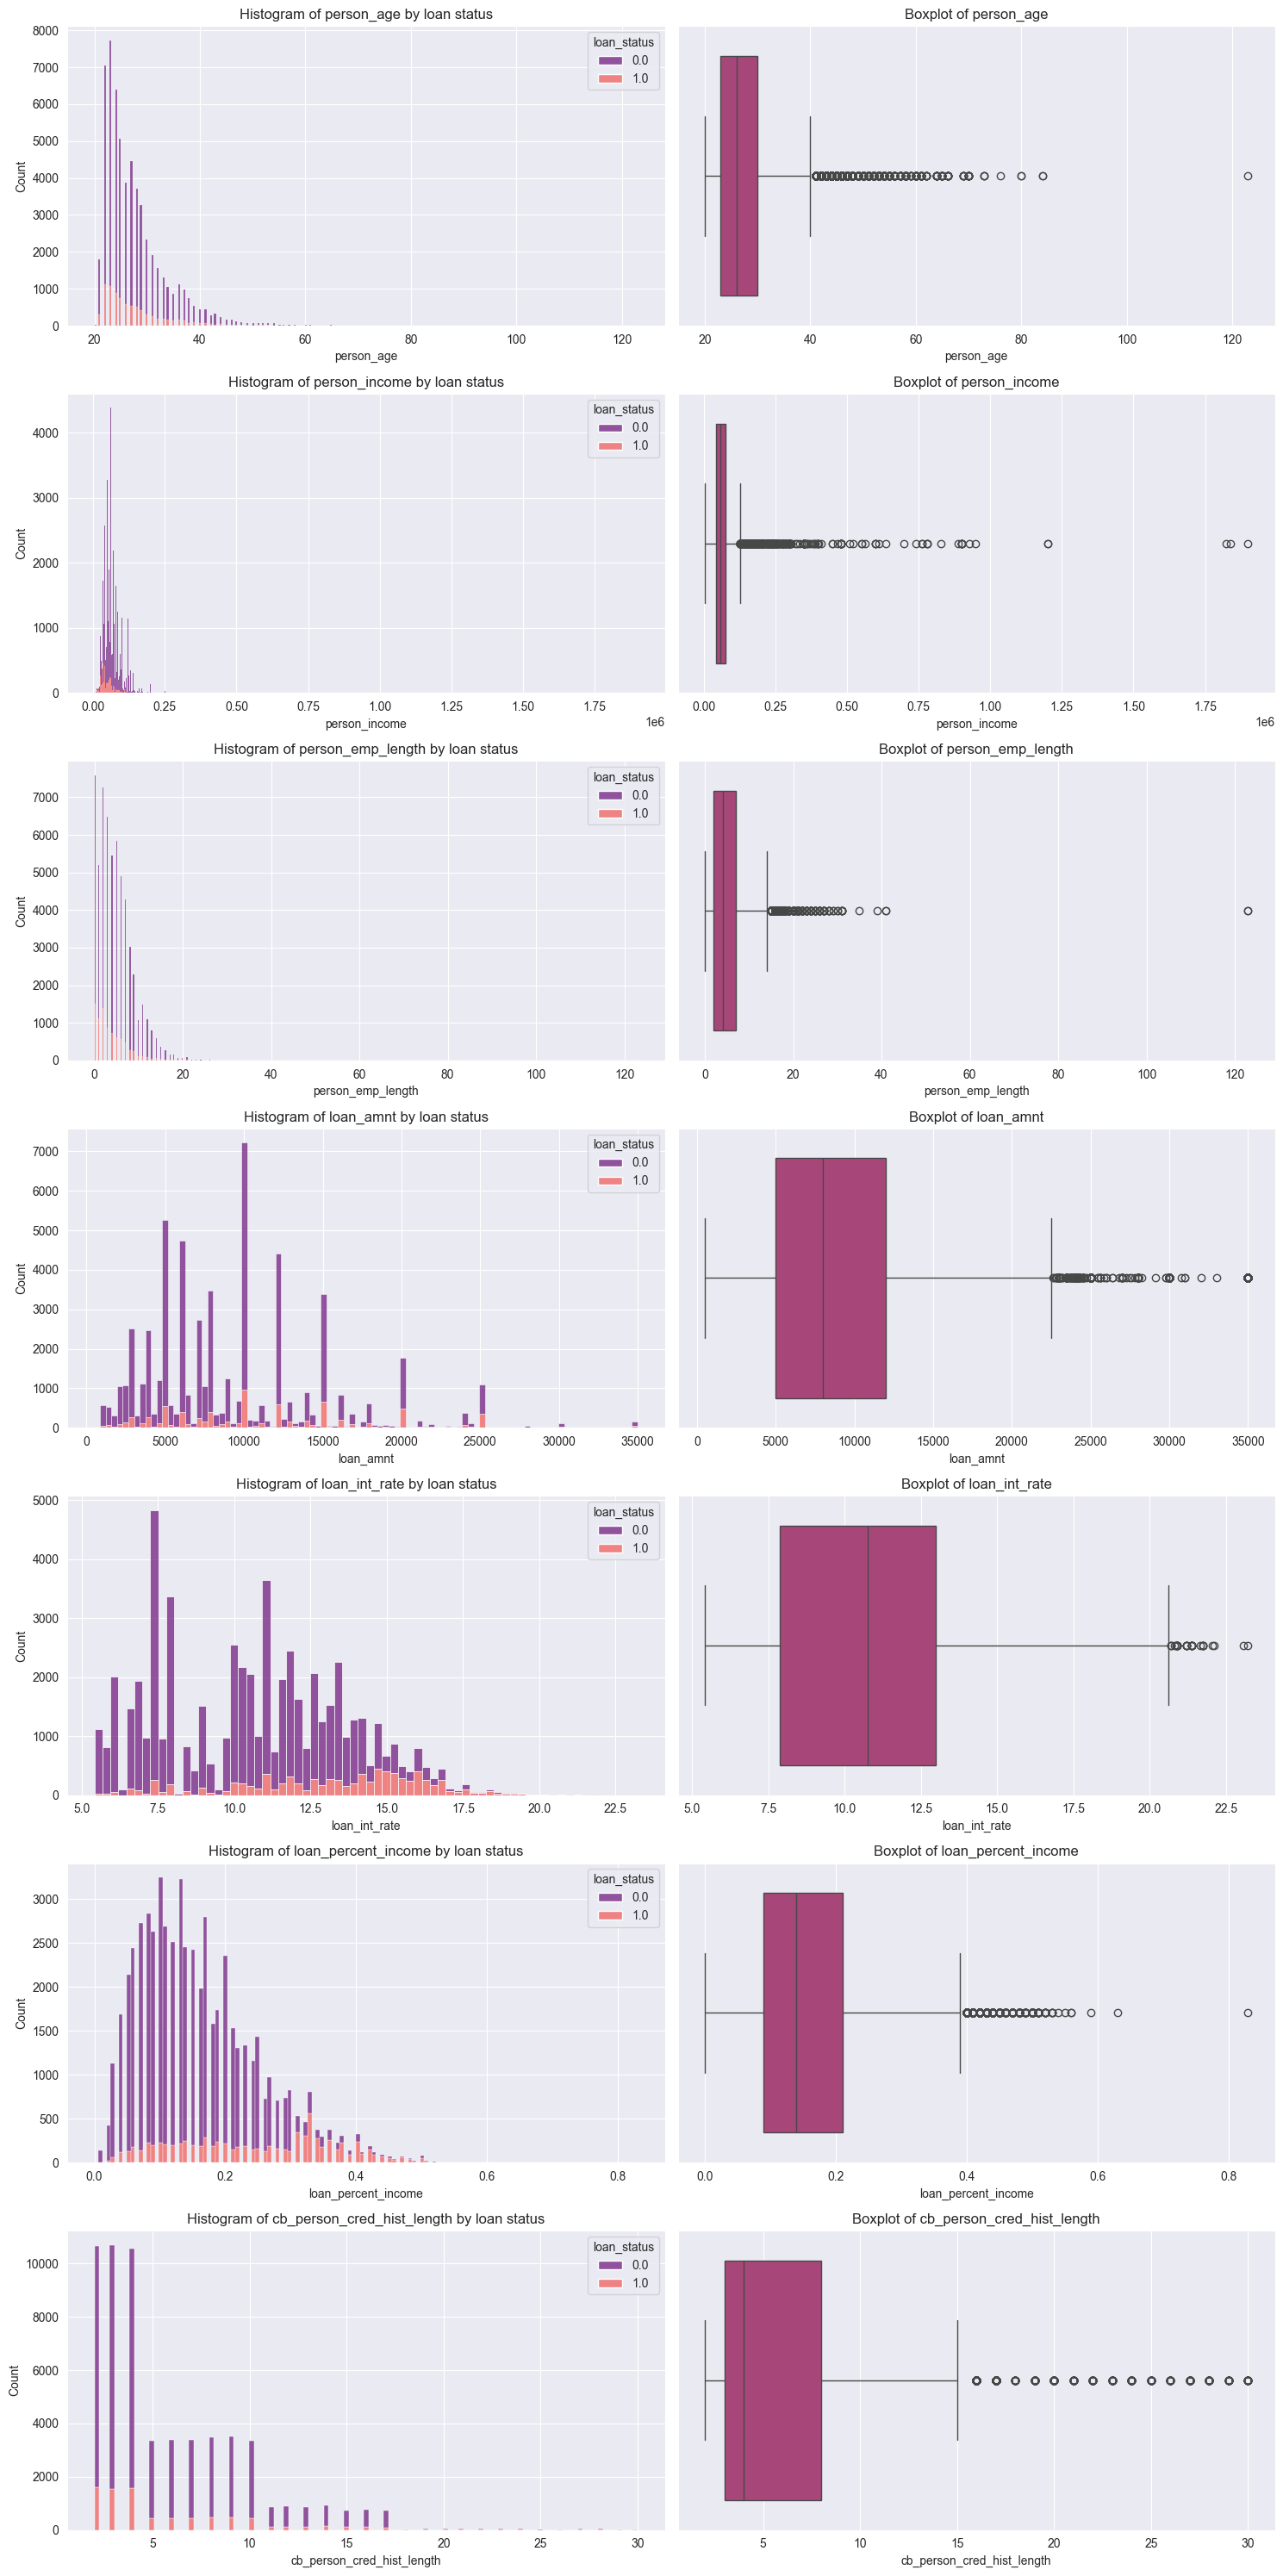

In [22]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

sns.set_style('darkgrid')

list_of_columns = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 
                   'loan_percent_income', 'cb_person_cred_hist_length']

fig, axs = plt.subplots(len(list_of_columns), 2, figsize=(15, 30))

for i, columns_name in enumerate(list_of_columns):
    sns.histplot(data=df, x=columns_name, hue='loan_status',
                 multiple='stack', palette='magma', ax=axs[i, 0])

    axs[i, 0].set_title(f'Histogram of {columns_name} by loan status')

    sns.boxplot(data=df, x=columns_name, palette='magma', ax=axs[i, 1])
  
    axs[i, 1].set_title(f'Boxplot of {columns_name}')

plt.tight_layout()

plt.show()

warnings.simplefilter(action='default', category=FutureWarning)